#이미지 코드

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset, random_split, Dataset
import numpy as np
import cv2
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pandas as pd
import random
import os
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import ConcatDataset
from tqdm import tqdm
import zipfile
import shutil


#이미지 불러오기
drive_path = '/content/drive/MyDrive/img_dataset.zip'
local_path = '/content'

shutil.copy(drive_path, local_path)

with zipfile.ZipFile("/content/img_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/temp")

# fall 압축 해제
with zipfile.ZipFile("/content/temp/fall.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")
# non-fall 압축 해제
with zipfile.ZipFile("/content/temp/non-fall.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")




#이미지 전처리
def pre_process_thermal_images(src_root, dst_root):
    categories = ['fall', 'non-fall']

    for cat in categories:
        src_path = os.path.join(src_root, cat)
        dst_path = os.path.join(dst_root, cat)
        os.makedirs(dst_path, exist_ok=True)

        files = os.listdir(src_path)
        print(f"{cat} 카테고리 변환 중...")

        for f in tqdm(files):
            img_path = os.path.join(src_path, f)
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

            if img is not None:
                normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
                normalized = normalized.astype(np.uint8)
                colored = cv2.applyColorMap(normalized, cv2.COLORMAP_JET)

                cv2.imwrite(os.path.join(dst_path, f), colored)

pre_process_thermal_images('/content/dataset', '/content/colored_dataset')



def seed_everything(seed=42):
    # 파이썬 자체 난수 고정
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 넘파이 난수 고정
    np.random.seed(seed)

    # 파이토치 CPU 및 GPU 난수 고정
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 대비

    # cuDNN 백엔드 결정론적 연산 설정 (동기화)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 안개 노이즈
def apply_steam_noise(image, severity=0.5):
    img_np = np.array(image).astype(np.float32)
    h, w = img_np.shape[:2]
    mask = np.random.rand(h, w).astype(np.float32)
    mask = cv2.GaussianBlur(mask, (101, 101), 0)
    mask = cv2.normalize(mask, None, 0, 1, cv2.NORM_MINMAX)
    mask = mask * severity
    if len(img_np.shape) == 3:
        mask = np.expand_dims(mask, axis=2)
    blurred = cv2.GaussianBlur(img_np, (9,9), 0)
    img_np = img_np * (1 - mask * 0.4) + blurred * (mask * 0.4)

    steam_layer = np.ones_like(img_np) * 255
    img_np = img_np * (1 - mask * 0.3) + steam_layer * (mask * 0.3)

    return Image.fromarray(
        np.clip(img_np, 0, 255).astype(np.uint8)
    )
class RandomApplySteam:
    def __init__(self, p=0.3, severity=0.3):
        self.p = p
        self.severity = severity
    def __call__(self, img):
        if np.random.rand() < self.p:
            return apply_steam_noise(img, severity=self.severity)
        return img

class ThermalFluctuation(object):
    def __init__(self, intensity=0.01, blur_kernel=31):
        self.intensity = intensity
        self.blur_kernel = blur_kernel

    def __call__(self, tensor):
        noise = np.random.normal( loc=0.0,  scale=self.intensity,
            size=(tensor.shape[1], tensor.shape[2])
        ).astype(np.float32)

        noise = cv2.GaussianBlur( noise, (self.blur_kernel, self.blur_kernel),  0  )
        noise = torch.from_numpy(noise)
        noise = noise.unsqueeze(0).repeat(tensor.shape[0], 1, 1)
        tensor = tensor + noise

        return torch.clamp(tensor, 0.0, 1.0)

# 커스텀 데이터셋
class ThermalDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

        #원본 Dataset 찾기
        curr_dataset = subset
        while isinstance(curr_dataset, Subset):
            curr_dataset = curr_dataset.dataset
        self.root_dataset = curr_dataset

    def __getitem__(self, index):
        real_index = index
        curr_subset = self.subset
        while isinstance(curr_subset, Subset):
            real_index = curr_subset.indices[real_index]
            curr_subset = curr_subset.dataset

        path, label = self.root_dataset.samples[real_index]



        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)

        # BGR → RGB 변환
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(img)


        if self.transform:
            image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.subset)

seed_everything(42)

# 전처리 설정
data_transforms = transforms.Compose([
    RandomApplySteam(p=0.5, severity=0.4),
    transforms.RandomResizedCrop(224,  scale=(0.93, 1.0), ratio=(1.45, 2.0)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    ThermalFluctuation(intensity=0.01,  blur_kernel=31),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

np.random.seed(42)

# 데이터 로드
full_dataset = datasets.ImageFolder('/content/colored_dataset')
fall_class_idx = full_dataset.class_to_idx['fall']



# 훈련/검증/테스트 분할

all_indices = list(range(len(full_dataset)))
train_size = int(0.8 * len(all_indices))
val_size = int(0.1 * len(all_indices))
test_size = len(all_indices) - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    full_dataset, [train_size, val_size, test_size]
)

base_train_data = ThermalDataset(train_indices, transform=data_transforms)
train_thermal_data = ThermalDataset(train_indices, transform=data_transforms)
val_thermal_data   = ThermalDataset(val_indices,   transform=val_data_transforms)
test_thermal_data  = ThermalDataset(test_indices,  transform=val_data_transforms)


train_loader = DataLoader(train_thermal_data, batch_size=64, shuffle=True,  num_workers=2,pin_memory=True)
val_loader   = DataLoader(val_thermal_data,   batch_size=64, shuffle=False, num_workers=2,pin_memory=True)
test_loader  = DataLoader(test_thermal_data,  batch_size=64, shuffle=False, num_workers=2,pin_memory=True)

total_train_samples = len(train_thermal_data)
total_val_samples = len(val_thermal_data)



model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


labels = [label for _, label in full_dataset.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights[0] = class_weights[0] * 1.5
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)

# 학습 루프
best_acc = 0
epochs = 5
print("학습을 시작합니다...")
start_time = time.time()

history = {
    'epoch': [],
    'train_acc': [], 'val_acc': [],
    'train_loss': [], 'val_loss': []
}

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        train_loss += loss.item() * inputs.size(0)
    # 검증
    model.eval()
    val_loss = 0.0
    val_correct = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            val_outputs = model(inputs)
            val_loss_batch = criterion(val_outputs, labels)
            val_loss += val_loss_batch.item() * inputs.size(0)

    train_acc = train_correct.item() / train_size
    val_acc   = val_correct.item()   / val_size
    train_loss = train_loss / train_size
    val_loss = val_loss / val_size


    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}')

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')

#훈련 시간 계산
end_time = time.time()
total_duration = end_time - start_time
print(f"\nTotal Training Time: {total_duration // 60:.0f}분 {total_duration % 60:.0f}초")

print("\n")


model.load_state_dict(torch.load('best_model.pt'))
model.eval()

test_preds, test_labels_list = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        thermal_prob = probs[:, fall_class_idx]
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

cm = confusion_matrix(test_labels_list, test_preds)
report = classification_report(test_labels_list, test_preds, target_names=['Fall', 'Non-Fall'])



#직접 촬영한 데이터셋 테스트
new_test_dataset_raw = datasets.ImageFolder('/content/drive/MyDrive/fallguard/final_dataset')
new_test_indices = list(range(len(new_test_dataset_raw)))
new_test_subset = Subset(new_test_dataset_raw, new_test_indices)
new_test_thermal_data = ThermalDataset(new_test_subset, transform=val_data_transforms)
new_test_loader = DataLoader(
    new_test_thermal_data,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

model = model.to(device)
model.load_state_dict(torch.load('/content/best_model.pt'))
model.eval()

test_probs, test_labels_list = [], []
with torch.no_grad():
    for inputs, labels in new_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        fall_probs = probs[:, fall_class_idx].cpu().numpy()
        test_probs.extend(fall_probs)
        test_labels_list.extend(labels.cpu().numpy())

threshold=0.78
custom_preds = [1 if p >= threshold else 0 for p in test_probs]
cm = confusion_matrix(test_labels_list, custom_preds)
report = classification_report(test_labels_list, custom_preds, target_names=['Fall', 'Non-Fall'])




fall 카테고리 변환 중...


100%|██████████| 2000/2000 [00:50<00:00, 39.42it/s]


non-fall 카테고리 변환 중...


100%|██████████| 4000/4000 [01:37<00:00, 41.21it/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 65.6MB/s]


학습을 시작합니다...
Epoch 1/5 | Train Loss: 0.2437 Train Acc: 0.8129 | Val Loss: 0.0077 Val Acc: 1.0000
Epoch 2/5 | Train Loss: 0.0043 Train Acc: 0.9992 | Val Loss: 0.0018 Val Acc: 1.0000
Epoch 3/5 | Train Loss: 0.0017 Train Acc: 0.9998 | Val Loss: 0.0010 Val Acc: 1.0000
Epoch 4/5 | Train Loss: 0.0010 Train Acc: 0.9996 | Val Loss: 0.0008 Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.0013 Train Acc: 0.9998 | Val Loss: 0.0039 Val Acc: 0.9967

Total Training Time: 10분 20초



Test Confusion Matrix:
[[190   0]
 [  0 410]]
Test Classification Report:
              precision    recall  f1-score   support

        Fall       1.00      1.00      1.00       190
    Non-Fall       1.00      1.00      1.00       410

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#오디오 코드


In [ ]:
# ── 셀 1: 드라이브 마운트 + 압축 해제 ──────────────────────────────
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

base_path   = '/content/dataset/audio_dataset'
danger_path = os.path.join(base_path, 'danger_custom')
normal_path = os.path.join(base_path, 'normal_custom')

with zipfile.ZipFile('/content/drive/MyDrive/fallguard/audio_dataset.zip', 'r') as z:
    z.extractall('/content/dataset')

with zipfile.ZipFile('/content/drive/MyDrive/fallguard/audio_test_dataset.zip', 'r') as z:
    z.extractall('/content/test_dataset')

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

# ── 셀 2: 샘플 시각화 ──────────────────────────────────────────────
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("=== 경로 확인 ===")
for name, path in [("위험", danger_path), ("정상", normal_path)]:
    print(f"  {name}: {path}  [{'존재' if os.path.exists(path) else '없음'}]")

SR = 22050

danger_files = [f for f in os.listdir(danger_path) if f.endswith('.wav')]

if not danger_files:
    print("danger_custom 폴더에 .wav 파일이 없습니다.")
else:
    sample_path = os.path.join(danger_path, danger_files[0])
    print(f"샘플: {danger_files[0]}")

    y, sr = librosa.load(sample_path, sr=SR)

    S_dB = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr),
        ref=np.max
    )

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Danger Sample - {danger_files[0]}")
    plt.tight_layout()
    plt.show()

# ── 셀 3: 파일 개수 확인 ───────────────────────────────────────────
print(f"위험: {len([f for f in os.listdir(danger_path) if f.endswith('.wav')])}개")
print(f"정상: {len([f for f in os.listdir(normal_path) if f.endswith('.wav')])}개")

# ── 셀 4: 전처리 ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

SR = 22050
DURATION = 3
N_MELS = 128
MAX_LEN = 128
ENERGY_THRESHOLD = 0.02

def get_rms_energy(file_path):
    y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
    return np.sqrt(np.mean(y**2))

def extract_melspectrogram(file_path):
    y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
    target_len = SR * DURATION
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    S_dB = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS),
        ref=np.max
    )
    if S_dB.shape[1] < MAX_LEN:
        S_dB = np.pad(S_dB, ((0, 0), (0, MAX_LEN - S_dB.shape[1])))
    else:
        S_dB = S_dB[:, :MAX_LEN]
    return S_dB

X, y = [], []

for f in os.listdir(danger_path):
    if f.endswith('.wav'):
        file_path = os.path.join(danger_path, f)
        if get_rms_energy(file_path) >= ENERGY_THRESHOLD:
            X.append(extract_melspectrogram(file_path))
            y.append(1)

for f in os.listdir(normal_path):
    if f.endswith('.wav'):
        X.append(extract_melspectrogram(os.path.join(normal_path, f)))
        y.append(0)

X = np.array(X)[..., np.newaxis]
y = np.array(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# 테스트 데이터
test_danger_path = '/content/test_dataset/test/danger'
test_normal_path = '/content/test_dataset/test/normal'

X_test, y_test = [], []

for f in os.listdir(test_danger_path):
    if f.endswith('.wav'):
        X_test.append(extract_melspectrogram(os.path.join(test_danger_path, f)))
        y_test.append(1)

for f in os.listdir(test_normal_path):
    if f.endswith('.wav'):
        X_test.append(extract_melspectrogram(os.path.join(test_normal_path, f)))
        y_test.append(0)

X_test = np.array(X_test)[..., np.newaxis]
y_test = np.array(y_test)

print(f"train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")
print(f"danger: {sum(y)}  normal: {len(y) - sum(y)}")

# ── 셀 5: 모델 정의 + 학습 ─────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

class F1Callback(callbacks.Callback):
    def __init__(self, val_data):
        self.val_x, self.val_y = val_data

    def on_epoch_end(self, epoch, logs=None):
        y_pred = (self.model.predict(self.val_x, verbose=0) > 0.5).flatten()
        tp = np.sum((y_pred == 1) & (self.val_y == 1))
        fp = np.sum((y_pred == 1) & (self.val_y == 0))
        fn = np.sum((y_pred == 0) & (self.val_y == 1))
        precision = tp / (tp + fp + 1e-7)
        recall    = tp / (tp + fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        logs['val_f1'] = f1
        print(f"  val_f1: {f1:.4f}")

model = models.Sequential([
    layers.Input(shape=(N_MELS, MAX_LEN, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

f1_callback = F1Callback(val_data=(X_val, y_val))

early_stop = callbacks.EarlyStopping(
    monitor='val_f1',
    mode='max',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[f1_callback, early_stop],
    class_weight={0: 2.0, 1: 1.0}
)

# ── 셀 6: 성능 평가 ────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.275).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['normal', 'danger']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'danger'],
            yticklabels=['normal', 'danger'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ── 셀 7: 모델 저장 ────────────────────────────────────────────────
model.save('/content/drive/MyDrive/fallguard/audio_model.keras')
print("저장 완료")

#### 셀1 드라이브랑 라이브러리 업로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torchvision import models, transforms
import numpy as np
import librosa
import tensorflow as tf
from PIL import Image
import cv2

Mounted at /content/drive


#### 셀2 이미지 + 오디오 모델 로드

드라이브 내 MyDrive 내 fallgurad내에 파일 저장해야 실행 가능

In [ ]:
# 오디오 모델 (TensorFlow)
audio_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/fallguard/audio_model.keras'
)

# 이미지 모델 (PyTorch)
image_model = models.mobilenet_v2(pretrained=False)
in_features = image_model.classifier[1].in_features
image_model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)
image_model.load_state_dict(
    torch.load('/content/drive/MyDrive/fallguard/best_model_dataset.pt',
               map_location='cpu')
)
image_model.eval()

print("두 모델 로드 완료")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


두 모델 로드 완료


#### 셀3 Late Fusion 함수로 모델 합침

In [ ]:
SR = 22050
DURATION = 3
N_MELS = 128
MAX_LEN = 128

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def get_audio_prob(wav_path):
    y, sr = librosa.load(wav_path, sr=SR, duration=DURATION)
    target_len = SR * DURATION
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    S_dB = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS),
        ref=np.max
    )
    if S_dB.shape[1] < MAX_LEN:
        S_dB = np.pad(S_dB, ((0, 0), (0, MAX_LEN - S_dB.shape[1])))
    else:
        S_dB = S_dB[:, :MAX_LEN]
    inp = S_dB[np.newaxis, ..., np.newaxis]
    prob = audio_model.predict(inp, verbose=0)[0][0]
    return float(prob)  # danger 확률


def get_image_prob(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return 0.0
    # normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
    normalized = np.uint8(normalized)
    colored = cv2.applyColorMap(normalized, cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    image = img_transform(Image.fromarray(colored)).unsqueeze(0)
    #rgb_img = cv2.cvtColor(normalized, cv2.COLOR_BGR2RGB)
    #image = img_transform(Image.fromarray(rgb_img)).unsqueeze(0)
    image = image.to(next(image_model.parameters()).device)
    with torch.no_grad():
        probs = torch.softmax(image_model(image), dim=1)
    return float(probs[0][0])  # fall 확률

def late_fusion(wav_path, img_path, threshold=0.5, audio_w=0.5, image_w=0.5):
    audio_prob = get_audio_prob(wav_path)
    image_prob = get_image_prob(img_path)
    final_score = audio_w * audio_prob + image_w * image_prob
    result = "위험" if final_score > threshold else "정상"
    print(f"오디오 위험 확률: {audio_prob:.3f}")
    print(f"이미지 위험 확률: {image_prob:.3f}")
    print(f"최종 점수: {final_score:.3f} → {result}")
    return result

###셀4 결과 (파일 넣는 곳)

결과값 예시

오디오 위험 확률: 0.705

이미지 위험 확률: 1.000

최종 점수: 0.852 → 위험

위험


결과값 해석

오디오는 이 오디오의 사고 발생 확률(위험)을 0.705로 보고 이미지는 1.00으로 봄. 이는 최종 점수는 0.852가 되고 85%의 확률로 위험하다는 것을 의미. 그래서 결과값이 위험이 나옴.

In [ ]:
late_fusion(
    wav_path='/content/drive/MyDrive/fallguard/audio_dataset/audio_dataset/danger_custom/03-02-11-01-23-110-02-02-02-11.wav',
    img_path='/content/drive/MyDrive/fallguard/img_dataset/fall/fall/image_t_999.png'
)

오디오 위험 확률: 0.705
이미지 위험 확률: 0.000
최종 점수: 0.352 → 정상


'정상'

# 셀5 영상-> 초 단위 분할 후 이미지 오디오 추출
드라이브 내 MyDrive 내 fallgurad내에 파일 저장 후 analyze_video에 경로 넣고 실행시켜야 함

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



영상 길이: 4초
오디오 추출 완료

0초


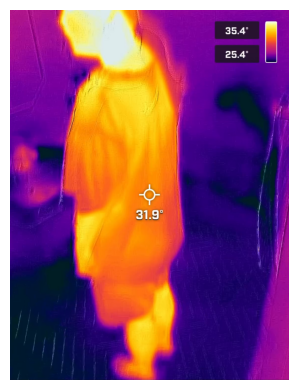

0초 오디오 구간 (0s ~ 3s):


오디오 위험 확률: 0.755
이미지 위험 확률: 0.019
최종 점수: 0.387 → 정상

1초


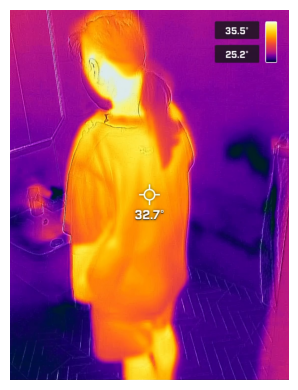

1초 오디오 구간 (0s ~ 3s):


오디오 위험 확률: 0.755
이미지 위험 확률: 0.031
최종 점수: 0.393 → 정상

2초


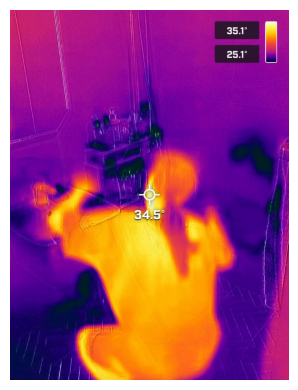

2초 오디오 구간 (1s ~ 4s):


오디오 위험 확률: 0.673
이미지 위험 확률: 0.356
최종 점수: 0.514 → 위험

3초


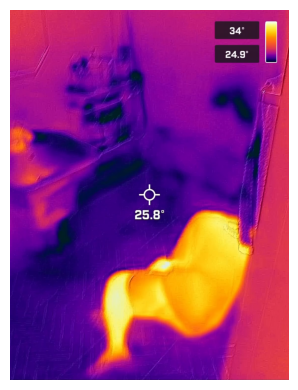

3초 오디오 구간 (2s ~ 5s):


오디오 위험 확률: 0.347
이미지 위험 확률: 0.467
최종 점수: 0.407 → 정상

총 4초 중 위험 감지: 1회


In [ ]:
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd
from moviepy.editor import VideoFileClip

def analyze_video(video_path):
    video = VideoFileClip(video_path)
    total_duration = int(video.duration)
    print(f"영상 길이: {total_duration}초")
    audio_path = "/content/extracted_audio.wav"
    video.audio.write_audiofile(audio_path, fps=SR, verbose=False, logger=None)
    print("오디오 추출 완료")
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    results = []

    for sec in range(total_duration):
        print(f"\n{'='*40}")
        print(f"{sec}초")
        # 프레임 추출
        cap.set(cv2.CAP_PROP_POS_FRAMES, sec * fps)
        ret, frame = cap.read()
        if not ret:
            continue
        img_path = f"/content/temp_frame_{sec}.png"
        cv2.imwrite(img_path, frame)
        # 오디오 추출
        start = max(0, sec - 1)
        audio_chunk, sr = librosa.load(audio_path, sr=SR, offset=start, duration=DURATION)
        chunk_path = f"/content/temp_audio_{sec}.wav"
        sf.write(chunk_path, audio_chunk, sr)
        #프레임 이미지 출력
        plt.figure(figsize=(5, 4))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        #오디오 출력
        print(f"{sec}초 오디오 구간 ({start}s ~ {start+DURATION}s):")
        ipd.display(ipd.Audio(chunk_path, rate=sr))
        # 위험 판단
        result = late_fusion(chunk_path, img_path)
        results.append({"시간": f"{sec}초", "결과": result})
    cap.release()

    # 결과
    print(f"\n{'='*40}")
    danger_count = sum(1 for r in results if r["결과"] == "위험")
    print(f"총 {total_duration}초 중 위험 감지: {danger_count}회")
    return results

!pip install moviepy soundfile -q
results=analyze_video("/content/drive/MyDrive/fallguard/넘어짐.mov")

알림 로직

카카오톡 보내기

In [ ]:
import requests
import json
from google.colab import userdata

def send_kakao_alert(status_msg):
    try:
        ACCESS_TOKEN = userdata.get('K_TOKEN')
    except:
        print("❌ 에러: 코랩 Secrets(열쇠 아이콘)에 'K_TOKEN'을 먼저 설정해주세요.")
        return 401

    url = "https://kapi.kakao.com/v2/api/talk/memo/default/send"
    headers = {
        "Authorization": f"Bearer {ACCESS_TOKEN}",
        "Content-Type": "application/x-www-form-urlencoded"
    }

    payload = {
        "object_type": "text",
        "text": f"🚨 [Fall Guard]\n{status_msg}",
        "link": {"web_url": "https://developers.kakao.com"},
        "button_title": "확인"
    }

    res = requests.post(url, headers=headers, data={"template_object": json.dumps(payload)})
    return res.status_code

In [ ]:
def check_fall_and_real_notify(analysis_results):
    REQUIRED_SECONDS = 4  # 연속시간
    continuous_count = 0
    is_alert_sent = False

    print(f"--- 실시간 알림 시스템 가동 중 ---")

    for r in analysis_results:
        if r["결과"] == "위험":
            continuous_count += 1
            if continuous_count >= REQUIRED_SECONDS and not is_alert_sent:
                # 카톡 전송
                msg = f"위험 상황 감지: 낙상이 의심됩니다!"
                status = send_kakao_alert(msg)

                if status == 200:
                    print(f"카톡 전송 성공")
                else:
                    print(f"전송실패 (상태코드: {status}) 토큰확인하기")
                is_alert_sent = True
        else:
            continuous_count = 0

    if not is_alert_sent:
        print("현재 상태 안전")

check_fall_and_real_notify(results)

--- 실시간 알림 시스템 가동 중 ---
현재 상태 안전


# 실시간 탐지 코드

In [ ]:
import os
import threading
import time
import cv2
import librosa
import numpy as np
import pyautogui
import sounddevice as sd
import tensorflow as tf
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

MODEL_DIR = r"C:\fallguard"
AUDIO_MODEL_PATH = os.path.join(MODEL_DIR, "audio_model.keras")
IMAGE_MODEL_PATH = os.path.join(MODEL_DIR, "best_model_FallWeight.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
audio_model = tf.keras.models.load_model(AUDIO_MODEL_PATH)

image_model = models.mobilenet_v2(pretrained=False)
in_features = image_model.classifier[1].in_features
image_model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2),
)
image_model.load_state_dict(torch.load(IMAGE_MODEL_PATH, map_location=device))
image_model.to(device)
image_model.eval()

print("이미지 및 오디오 모델 로드")

SR = 22050
DURATION = 3
N_MELS = 128
MAX_LEN = 128

img_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# 미러링 창 좌표
X_POS, Y_POS, WIDTH, HEIGHT = 100, 100, 300, 500

# 글로벌 멀티쓰레드 공유 변수
current_audio_prob = 0.0
data_lock = threading.Lock()


def audio_inference_thread():
    global current_audio_prob
    print("PC 마이크 실시간 감지")

    # 3초 치 마이크 소리 데이터를 담아둘 빈 리스트 생성 (AI 속도 22050Hz 기준)
    audio_buffer = np.zeros(SR * DURATION, dtype=np.float32)

    # 0.1초 단위로 쪼개서 수집하기 위한 샘플 개수
    chunk_samples = int(SR * 0.1)

    try:
        with sd.InputStream(
            samplerate=SR, channels=1, blocksize=chunk_samples, dtype="float32"
        ) as stream:
            while True:
                # 0.1초 치 실시간 소리 긁어오기
                data, overflowed = stream.read(chunk_samples)
                y_chunk = data.flatten()

                # 링 버퍼 방식으로 3초 데이터 유지
                audio_buffer = np.append(audio_buffer[len(y_chunk) :], y_chunk)
                y = audio_buffer.copy()

                S_dB = librosa.power_to_db(
                    librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS),
                    ref=np.max,
                )

                if S_dB.shape[1] < MAX_LEN:
                    S_dB = np.pad(S_dB, ((0, 0), (0, MAX_LEN - S_dB.shape[1])))
                else:
                    S_dB = S_dB[:, :MAX_LEN]

                inp = S_dB[np.newaxis, ..., np.newaxis]

                # 텐서플로우 추론
                prob = audio_model.predict(inp, verbose=0)[0][0]

                with data_lock:
                    current_audio_prob = float(prob)

    except Exception as e:
        print(f"오디오 쓰레드 크래시: {e}")

if __name__ == "__main__":
    audio_thread = threading.Thread(target=audio_inference_thread, daemon=True)
    audio_thread.start()

    print("--- 실시간 감지---")

    while True:
        screenshot = pyautogui.screenshot(region=(X_POS, Y_POS, WIDTH, HEIGHT))
        frame = cv2.cvtColor(np.array(screenshot), cv2.COLOR_RGB2BGR)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
        normalized = np.uint8(normalized)
        colored = cv2.applyColorMap(normalized, cv2.COLORMAP_JET)
        colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)

        image_tensor = img_transform(Image.fromarray(colored)).unsqueeze(0).to(device)

        with torch.no_grad():
            probs = torch.softmax(image_model(image_tensor), dim=1)
        local_image_prob = float(probs[0][0])

        with data_lock:
            local_audio_prob = current_audio_prob

        # Late Fusion
        final_fusion_score = 0.3 * local_audio_prob + 0.7 * local_image_prob
        result = "DANGER" if final_fusion_score > 0.5 else "NORMAL"

        bg_color = (0, 0, 255) if result == "DANGER" else (0, 255, 0)
        cv2.rectangle(frame, (0, 0), (WIDTH, 90), bg_color, -1)

        cv2.putText(
            frame,
            f"STATUS: {result}",
            (15, 35),
            cv2.FONT_HERSHEY_DUPLEX,
            0.7,
            (255, 255, 255),
            2,
        )
        cv2.putText(
            frame,
            f"SCORE: {final_fusion_score:.3f}",
            (15, 70),
            cv2.FONT_HERSHEY_DUPLEX,
            0.6,
            (255, 255, 255),
            1,
        )

        cv2.putText(
            frame,
            f"Audio: {local_audio_prob*100:.1f}%",
            (10, HEIGHT - 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            1,
        )
        cv2.putText(
            frame,
            f"Image: {local_image_prob*100:.1f}%",
            (10, HEIGHT - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            1,
        )

        cv2.imshow("FallGuard", frame)

        if cv2.waitKey(1)==ord("q"):
            break

    cv2.destroyAllWindows()

알림 로직 추가 실시간 탐지 버전

In [ ]:
import os
import threading
import time
import json
import cv2
import librosa
import numpy as np
import pyautogui
import requests
import sounddevice as sd
import tensorflow as tf
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

#일정 시간마다 토큰을 재발급 받아야함
KAKAO_TOKEN = "QLiHkao_VS8I7oM2uCJN0wSYLUaZdzIuAAAAAQoXAc8AAAGeWF_FKk41iD77kjRL"

def send_kakao_alert(status_msg):
    url = "https://kapi.kakao.com/v2/api/talk/memo/default/send"
    headers = {
        "Authorization": f"Bearer {KAKAO_TOKEN}",
        "Content-Type": "application/x-www-form-urlencoded"
    }
    payload = {
        "object_type": "text",
        "text": f"🚨 [Fall Guard 실시간 알림]\n\n{status_msg}",
        "link": {"web_url": "https://developers.kakao.com"},
        "button_title": "확인"
    }

    post_data = {
        "template_object": json.dumps(payload, ensure_ascii=False)
    }

    try:
        res = requests.post(url, headers=headers, data=post_data)

        if res.status_code == 401:
            print(f"카카오 서버 상세 에러 메시지: {res.json()}")

        return res.status_code
    except Exception as e:
        print(f"카톡 전송 중 네트워크 에러: {e}")
        return 500

#알림 변수들
last_alert_time = 0        #마지막으로 알림을 보낸 시점
danger_start_time = None   #위험 상황이 시작된 시점
ALERT_COOLDOWN = 10        #무한 알림 방지
REQUIRED_DANGER_DURATION = 3.0  #위험 3초 지속 시 알림 발생

MODEL_DIR = r"/Users/jungyunjin/Desktop/fallguard"
AUDIO_MODEL_PATH = os.path.join(MODEL_DIR, "audio_model.keras")
IMAGE_MODEL_PATH = os.path.join(MODEL_DIR, "best_model_FallWeight.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 하드웨어 장치: {device}")

audio_model = tf.keras.models.load_model(AUDIO_MODEL_PATH)

image_model = models.mobilenet_v2(pretrained=False)
in_features = image_model.classifier[1].in_features
image_model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2),
)
image_model.load_state_dict(torch.load(IMAGE_MODEL_PATH, map_location=device))
image_model.to(device)
image_model.eval()

print("이미지 및 오디오 AI 모델 로드 완료")

SR = 22050
DURATION = 3
N_MELS = 128
MAX_LEN = 128

img_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

#미러링 창 좌표
X_POS, Y_POS, WIDTH, HEIGHT = 100, 100, 300, 500

# 글로벌 멀티쓰레드 공유 변수
current_audio_prob = 0.0
data_lock = threading.Lock()


def audio_inference_thread():
    """ PC 마이크 소리를 실시간으로 긁어와 3초 버퍼로 추론하는 서브 쓰레드 """
    global current_audio_prob
    print("PC 마이크 실시간 감지 가동 중...")

    # 3초 분량의 소리 데이터를 담아둘 빈 링 버퍼 생성
    audio_buffer = np.zeros(SR * DURATION, dtype=np.float32)

    # 0.1초 단위로 쪼개서 수집하기 위한 샘플 개수
    chunk_samples = int(SR * 0.1)

    try:
        with sd.InputStream(
            samplerate=SR, channels=1, blocksize=chunk_samples, dtype="float32"
        ) as stream:
            while True:
                # 0.1초치 실시간 소리 긁어오기
                data, overflowed = stream.read(chunk_samples)
                y_chunk = data.flatten()

                # 링 버퍼 방식으로 3초 데이터 유지
                audio_buffer = np.append(audio_buffer[len(y_chunk) :], y_chunk)
                y = audio_buffer.copy()

                S_dB = librosa.power_to_db(
                    librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS),
                    ref=np.max,
                )

                if S_dB.shape[1] < MAX_LEN:
                    S_dB = np.pad(S_dB, ((0, 0), (0, MAX_LEN - S_dB.shape[1])))
                else:
                    S_dB = S_dB[:, :MAX_LEN]

                inp = S_dB[np.newaxis, ..., np.newaxis]

                # 텐서플로우 추론
                prob = audio_model.predict(inp, verbose=0)[0][0]

                with data_lock:
                    current_audio_prob = float(prob)

    except Exception as e:
        print(f"오디오 쓰레드 크래시 에러: {e}")


if __name__ == "__main__":

    audio_thread = threading.Thread(target=audio_inference_thread, daemon=True)
    audio_thread.start()

    print("--- 실시간 감지 ---")

    while True:
        screenshot = pyautogui.screenshot(region=(X_POS, Y_POS, WIDTH, HEIGHT))
        frame = cv2.cvtColor(np.array(screenshot), cv2.COLOR_RGB2BGR)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
        normalized = np.uint8(normalized)
        colored = cv2.applyColorMap(normalized, cv2.COLORMAP_JET)
        colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)

        image_tensor = img_transform(Image.fromarray(colored)).unsqueeze(0).to(device)

        with torch.no_grad():
            probs = torch.softmax(image_model(image_tensor), dim=1)
        local_image_prob = float(probs[0][0])

        with data_lock:
            local_audio_prob = current_audio_prob

        #Late Fusion
        final_fusion_score = 0.3 * local_audio_prob + 0.7 * local_image_prob
        result = "DANGER" if final_fusion_score > 0.5 else "NORMAL"

        current_time = time.time()

        if result == "DANGER":
            if danger_start_time is None:
                danger_start_time = current_time

            #연속 몇초인지 계산
            elapsed_danger_time = current_time - danger_start_time

            #위험 지속 3초 및 보낸지 10초 지났으면
            if elapsed_danger_time >= REQUIRED_DANGER_DURATION:
                if current_time - last_alert_time > ALERT_COOLDOWN:
                    msg = f"위험 상황이 3초 이상 지속되었습니다! 즉시 확인이 필요합니다."

                    status = send_kakao_alert(msg)
                    if status == 200:
                        print("알림 전송 성공")
                    else:
                        print(f"알림 전송 실패 (오류 코드: {status})")

                    last_alert_time = current_time  #마지막 전송 시간 업데이트
        else:
            #타이머 리셋
            danger_start_time = None

        bg_color = (0, 0, 255) if result == "DANGER" else (0, 255, 0)
        cv2.rectangle(frame, (0, 0), (WIDTH, 90), bg_color, -1)

        cv2.putText(
            frame,
            f"STATUS: {result}",
            (15, 35),
            cv2.FONT_HERSHEY_DUPLEX,
            0.7,
            (255, 255, 255),
            2,
        )
        cv2.putText(
            frame,
            f"SCORE: {final_fusion_score:.3f}",
            (15, 70),
            cv2.FONT_HERSHEY_DUPLEX,
            0.6,
            (255, 255, 255),
            1,
        )

        cv2.putText(
            frame,
            f"Audio: {local_audio_prob*100:.1f}%",
            (10, HEIGHT - 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            1,
        )
        cv2.putText(
            frame,
            f"Image: {local_image_prob*100:.1f}%",
            (10, HEIGHT - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            1,
        )

        cv2.imshow("FallGuard", frame)

        if cv2.waitKey(1) == ord("q"):
            break

    cv2.destroyAllWindows()